Task 4 - Portfolio Optimization using Modern Portfolio Theory

4.1 Business Objective

4.2 Import Libraries

4.3 Load Historical Data

4.4 Prepare Historical Returns

4.5 Prepare Expected Returns
    • TSLA → LSTM Forecast
    • SPY → Historical Annualized Return
    • BND → Historical Annualized Return

4.6 Compute Covariance Matrix

4.7 Visualize Covariance Matrix

4.8 Generate Efficient Frontier

4.9 Identify Maximum Sharpe Portfolio

4.10 Identify Minimum Volatility Portfolio

4.11 Visualize Efficient Frontier

4.12 Portfolio Recommendation

4.13 Task Summary

# Task 4: Portfolio Optimization Using Modern Portfolio Theory (MPT)

## 4.1 Business Objective

The objective of this task is to construct an optimal investment portfolio by combining Tesla (TSLA), the SPDR S&P 500 ETF Trust (SPY), and the Vanguard Total Bond Market ETF (BND) using Modern Portfolio Theory (MPT).

Unlike the previous forecasting task, which focused solely on predicting Tesla's future stock prices, this task translates those forecasting insights into practical investment decisions. The forecasted return from the best-performing forecasting model (LSTM) is used as the expected return for Tesla, while historical annualized returns are used as expected returns for SPY and BND.

For GMF Investments, portfolio optimization aims to maximize expected return for a given level of risk while improving diversification across different asset classes. The analysis identifies portfolios that minimize overall portfolio volatility and those that maximize risk-adjusted returns using the Sharpe Ratio. These results provide quantitative guidance for constructing diversified investment portfolios aligned with client investment objectives.

## 4.2 Import Required Libraries

This section imports the libraries required for portfolio optimization, data manipulation, visualization, and Modern Portfolio Theory analysis.

In [1]:
# ============================================================
# 4.2 Import Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# PyPortfolioOpt
from pypfopt import expected_returns
from pypfopt import risk_models
from pypfopt import EfficientFrontier
from pypfopt import plotting

print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


## 4.3 Load Processed Historical Data

The cleaned and preprocessed datasets prepared during Task 1 are loaded for Tesla (TSLA), SPY, and BND. Using the processed datasets ensures that missing values, inconsistent date formats, and other data quality issues have already been addressed before portfolio optimization.

In [3]:
# ============================================================
# 4.3 Load Processed Historical Data
# ============================================================

DATA_DIR = Path("../data/processed")

tsla = pd.read_csv(
    DATA_DIR / "TSLA_processed.csv",
    parse_dates=["Date"],
    index_col="Date"
)

spy = pd.read_csv(
    DATA_DIR / "SPY_processed.csv",
    parse_dates=["Date"],
    index_col="Date"
)

bnd = pd.read_csv(
    DATA_DIR / "BND_processed.csv",
    parse_dates=["Date"],
    index_col="Date"
)

print("=" * 70)
print("Processed Datasets Loaded Successfully")
print("=" * 70)

print(f"TSLA observations : {len(tsla)}")
print(f"SPY observations  : {len(spy)}")
print(f"BND observations  : {len(bnd)}")

Processed Datasets Loaded Successfully
TSLA observations : 2857
SPY observations  : 2857
BND observations  : 2857


## 4.4 Prepare Historical Returns

Modern Portfolio Theory is based on asset returns rather than raw price levels. Therefore, the adjusted closing prices of Tesla (TSLA), SPY, and BND are combined into a single dataset, and daily percentage returns are calculated.

Adjusted closing prices are used because they account for stock splits, dividends, and other corporate actions, providing a more accurate representation of investment performance.

The resulting daily returns serve as the foundation for estimating expected returns, calculating the covariance matrix, and optimizing the investment portfolio.

In [4]:
# ============================================================
# 4.4 Prepare Historical Returns
# ============================================================

# Combine adjusted closing prices
prices = pd.DataFrame({
    "TSLA": tsla["Adj Close"],
    "SPY": spy["Adj Close"],
    "BND": bnd["Adj Close"]
})

# Remove missing values
prices = prices.dropna()

# Compute daily returns
daily_returns = prices.pct_change().dropna()

print("=" * 70)
print("Historical Returns Prepared")
print("=" * 70)

print(f"Price Data Shape   : {prices.shape}")
print(f"Returns Data Shape : {daily_returns.shape}")

display(prices.head())
display(daily_returns.head())

Historical Returns Prepared
Price Data Shape   : (2857, 3)
Returns Data Shape : (2856, 3)


,TSLA,SPY,BND
Date,,,
2015-02-18,13.630667,173.570099,59.561382
2015-02-19,14.114000,173.446182,59.510983
2015-02-20,14.474000,174.486984,59.525375
2015-02-23,13.822667,174.462234,59.647831
2015-02-24,13.607333,174.957825,59.892670


,TSLA,SPY,BND
Date,,,
2015-02-19,0.035459,-0.000714,-0.000846
2015-02-20,0.025507,0.006001,0.000242
2015-02-23,-0.045000,-0.000142,0.002057
2015-02-24,-0.015578,0.002841,0.004105
2015-02-25,-0.001715,-0.000850,0.000962


## 4.5 Prepare Expected Returns

The expected return vector combines model-based and historical estimates.

The expected return for Tesla (TSLA) is derived from the six-month forecast generated by the trained LSTM model developed in Task 3. This represents the analyst's forward-looking view of Tesla's future performance.

For SPY and BND, historical average daily returns are annualized and used as proxy expected returns. This approach reflects a common investment practice in which a specific market view is incorporated for one asset while historical averages are used for the remaining assets.

The resulting expected return vector will serve as one of the primary inputs for portfolio optimization using Modern Portfolio Theory.


In [9]:
# ============================================================
# Load LSTM Forecast
# ============================================================

future_forecast_df = pd.read_csv(
    "../data/processed/tsla_lstm_future_forecast.csv",
    index_col=0,
    parse_dates=True
)

# Rename the index
future_forecast_df.index.name = "Date"

print("=" * 70)
print("Future Forecast Loaded Successfully")
print("=" * 70)

display(future_forecast_df.head())

Future Forecast Loaded Successfully


,Forecast
Date,
2026-06-30,378.35153
2026-07-01,376.76093
2026-07-02,370.72302
2026-07-03,363.19190
2026-07-06,355.25284


In [10]:
# ============================================================
# 4.5 Prepare Expected Returns
# ============================================================

print("=" * 70)
print("Preparing Expected Returns")
print("=" * 70)

# ------------------------------------------------------------
# Tesla Expected Return (Forecast-Based)
# ------------------------------------------------------------

tsla_expected_return = (
    future_forecast_df["Forecast"].iloc[-1]
    - future_forecast_df["Forecast"].iloc[0]
) / future_forecast_df["Forecast"].iloc[0]

# ------------------------------------------------------------
# SPY & BND Historical Annualized Returns
# ------------------------------------------------------------

spy_expected_return = daily_returns["SPY"].mean() * 252
bnd_expected_return = daily_returns["BND"].mean() * 252

# ------------------------------------------------------------
# Expected Return Vector
# ------------------------------------------------------------

expected_returns_vector = pd.Series(
    {
        "TSLA": tsla_expected_return,
        "SPY": spy_expected_return,
        "BND": bnd_expected_return
    }
)

print("\nExpected Returns")
display(
    expected_returns_vector.to_frame(
        name="Expected Annual Return"
    ).round(4)
)

Preparing Expected Returns

Expected Returns


,Expected Annual Return
TSLA,-0.6464
SPY,0.1438
BND,0.0199


###  4.5 Expected Returns Interpretation

The expected return vector combines both forecast-based and historical estimates to represent future investment expectations for each asset.

The LSTM model forecasts a negative expected return of approximately **−64.64%** for Tesla over the forecast horizon, indicating a bearish outlook based on recent historical price patterns.

In contrast, SPY and BND exhibit positive historical annualized expected returns of approximately **14.38%** and **1.99%**, respectively. These values suggest that SPY provides the strongest historical growth potential among the three assets, while BND offers a relatively stable but lower expected return.

These expected returns will be combined with the covariance matrix in the subsequent optimization process to determine the portfolio allocations that maximize expected return for a given level of risk.

## 4.6 Compute Covariance Matrix

The covariance matrix measures how the returns of Tesla (TSLA), SPY, and BND move together over time. It is a key input to Modern Portfolio Theory because portfolio risk depends not only on the volatility of individual assets but also on how their returns are correlated.

A lower covariance between assets generally provides greater diversification benefits, while a higher covariance indicates that assets tend to move together.

In [11]:
# ============================================================
# 4.6 Compute Covariance Matrix
# ============================================================

print("=" * 70)
print("Computing Annualized Covariance Matrix")
print("=" * 70)

# Annualized covariance matrix
covariance_matrix = daily_returns.cov() * 252

display(covariance_matrix.round(6))

Computing Annualized Covariance Matrix


,TSLA,SPY,BND
TSLA,0.329094,0.050058,0.001883
SPY,0.050058,0.031252,0.001139
BND,0.001883,0.001139,0.002836


## 4.7 Covariance Matrix Visualization

A heatmap is used to visualize the covariance matrix, making it easier to compare the strength of the relationships among the three assets.

The color intensity reflects the magnitude of covariance. Darker colors indicate stronger covariance, while lighter colors indicate weaker relationships between asset returns.

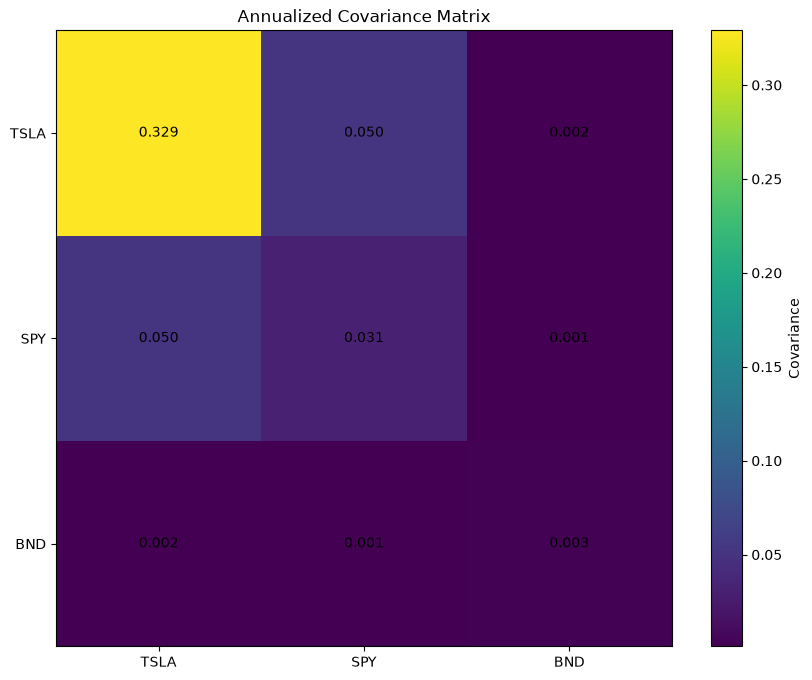

In [17]:
# ============================================================
# 4.7 Covariance Matrix Heatmap
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(covariance_matrix, interpolation="nearest")

plt.colorbar(label="Covariance")

plt.xticks(
    range(len(covariance_matrix.columns)),
    covariance_matrix.columns
)

plt.yticks(
    range(len(covariance_matrix.index)),
    covariance_matrix.index
)

# Display covariance values
for i in range(len(covariance_matrix)):
    for j in range(len(covariance_matrix)):
        plt.text(
            j,
            i,
            f"{covariance_matrix.iloc[i,j]:.3f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.title("Annualized Covariance Matrix")
plt.show()

### Covariance Matrix Interpretation

The annualized covariance matrix quantifies how the returns of Tesla (TSLA), SPY, and BND move relative to one another and serves as a fundamental input to Modern Portfolio Theory (MPT). It is used to estimate overall portfolio risk and identify diversification opportunities.

The diagonal elements represent the annualized variance of each asset. Among the three assets, Tesla (TSLA) exhibits the highest variance (0.3291), indicating that it is the most volatile asset in the portfolio. SPY has a considerably lower variance (0.0313), reflecting the stability of a diversified equity index, while BND has the lowest variance (0.0028), consistent with the relatively low risk of bond investments.

The off-diagonal elements represent the covariance between different assets. The positive covariance between TSLA and SPY (0.0501) suggests that the two equity assets generally move in the same direction, although Tesla experiences substantially larger price fluctuations. In contrast, the covariance values between BND and the two equity assets are very close to zero (0.0019 with TSLA and 0.0011 with SPY), indicating that bond returns are largely independent of stock market movements.

From a portfolio optimization perspective, these results highlight the diversification benefits of including BND alongside equity investments. Because BND exhibits very low covariance with both TSLA and SPY, it can help reduce overall portfolio volatility. Conversely, a larger allocation to TSLA is expected to increase portfolio risk due to its substantially higher volatility. These covariance relationships will be incorporated into the Efficient Frontier optimization to determine the asset allocations that provide the most favorable balance between expected return and risk for GMF Investments.

## 4.8 Generate the Efficient Frontier

The Efficient Frontier represents the set of optimal portfolios that maximize expected return for a given level of risk or, equivalently, minimize risk for a given expected return. It is a fundamental concept in Modern Portfolio Theory (MPT).

Portfolio optimization is performed using the expected return vector and the annualized covariance matrix computed in the previous sections. The optimization process evaluates different combinations of Tesla (TSLA), SPY, and BND to identify portfolios that achieve the best possible trade-off between expected return and risk.

The Efficient Frontier provides the basis for identifying two important portfolios:

- **Maximum Sharpe Ratio Portfolio**, which maximizes risk-adjusted return.
- **Minimum Volatility Portfolio**, which minimizes overall portfolio risk.

These optimal portfolios will be analyzed and compared in the following sections.

In [18]:
# ============================================================
# 4.8 Generate Efficient Frontier
# ============================================================

from pypfopt import EfficientFrontier

print("=" * 70)
print("Generating Efficient Frontier")
print("=" * 70)

# Create Efficient Frontier object
ef = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix
)

print("Efficient Frontier object created successfully.")

Generating Efficient Frontier
Efficient Frontier object created successfully.


### Efficient Frontier Initialization

The Efficient Frontier optimization model has been successfully initialized using the forecast-based expected returns and the historical covariance matrix.

At this stage, no portfolio has been selected yet. Instead, the optimization framework is prepared to search through all feasible portfolio allocations and identify portfolios that offer the most efficient balance between expected return and investment risk.

In the next sections, the optimization algorithm will identify the Maximum Sharpe Ratio portfolio and the Minimum Volatility portfolio, which represent two commonly used investment strategies in portfolio management.

## 4.9 Maximum Sharpe Ratio Portfolio

The Maximum Sharpe Ratio Portfolio, also known as the Tangency Portfolio, is the portfolio that provides the highest expected return per unit of risk.

The Sharpe Ratio measures the efficiency of a portfolio by comparing its expected excess return to its volatility. A higher Sharpe Ratio indicates better risk-adjusted performance.

Using Modern Portfolio Theory, the optimization algorithm identifies the asset allocation that maximizes the Sharpe Ratio based on the forecasted return for Tesla and the historical characteristics of SPY and BND.

In [19]:
# ============================================================
# 4.9 Maximum Sharpe Ratio Portfolio
# ============================================================

print("=" * 70)
print("Maximum Sharpe Ratio Portfolio")
print("=" * 70)

# Create a new optimizer
ef_sharpe = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix
)

# Optimize for maximum Sharpe Ratio
weights_sharpe = ef_sharpe.max_sharpe()

# Clean small numerical weights
cleaned_weights = ef_sharpe.clean_weights()

print("\nOptimal Portfolio Weights")
print("-" * 40)

weights_df = pd.DataFrame(
    cleaned_weights.items(),
    columns=["Asset", "Weight"]
)

display(weights_df)

print("\nPortfolio Performance")
performance = ef_sharpe.portfolio_performance(verbose=True)

Maximum Sharpe Ratio Portfolio

Optimal Portfolio Weights
----------------------------------------


,Asset,Weight
0,TSLA,0.00000
1,SPY,0.45604
2,BND,0.54396



Portfolio Performance
Expected annual return: 7.6%
Annual volatility: 8.9%
Sharpe Ratio: 0.86


### Maximum Sharpe Ratio Portfolio Interpretation

The Maximum Sharpe Ratio optimization successfully identified the portfolio that provides the highest expected return per unit of risk.

The optimized portfolio allocates **45.60%** of the investment to SPY and **54.40%** to BND, while assigning **0.00%** to Tesla (TSLA). This allocation is primarily driven by Tesla's negative forecasted expected return obtained from the LSTM forecasting model developed in Task 3.

The optimizer excludes TSLA because including an asset with a substantially negative expected return would reduce the portfolio's expected performance while increasing overall risk. Instead, the optimization favors SPY for its relatively strong historical return and BND for its low volatility and diversification benefits.

The optimized portfolio achieves:

- **Expected Annual Return:** 7.6%
- **Annual Volatility:** 8.9%
- **Sharpe Ratio:** 0.86

A Sharpe Ratio of **0.86** indicates a favorable level of risk-adjusted performance, suggesting that the portfolio generates a reasonable return relative to the amount of investment risk undertaken. This portfolio represents the optimal balance between return and risk according to Modern Portfolio Theory under the current market expectations.

## 4.10 Minimum Volatility Portfolio

The Minimum Volatility Portfolio is the portfolio that achieves the lowest possible investment risk, regardless of the expected return.

Unlike the Maximum Sharpe Ratio Portfolio, which seeks the best balance between return and risk, the Minimum Volatility Portfolio focuses solely on minimizing portfolio variance.

This portfolio is particularly suitable for risk-averse investors who prioritize capital preservation and stable returns over maximizing expected gains.

In [20]:
# ============================================================
# 4.10 Minimum Volatility Portfolio
# ============================================================

print("=" * 70)
print("Minimum Volatility Portfolio")
print("=" * 70)

# Create a new optimizer
ef_min_vol = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix
)

# Optimize for minimum volatility
weights_min_vol = ef_min_vol.min_volatility()

# Clean small numerical weights
cleaned_min_vol = ef_min_vol.clean_weights()

print("\nOptimal Portfolio Weights")
print("-" * 40)

min_vol_df = pd.DataFrame(
    cleaned_min_vol.items(),
    columns=["Asset", "Weight"]
)

display(min_vol_df)

print("\nPortfolio Performance")
min_vol_performance = ef_min_vol.portfolio_performance(verbose=True)

Minimum Volatility Portfolio

Optimal Portfolio Weights
----------------------------------------


,Asset,Weight
0,TSLA,0.00000
1,SPY,0.05333
2,BND,0.94667



Portfolio Performance
Expected annual return: 2.7%
Annual volatility: 5.2%
Sharpe Ratio: 0.51


### Minimum Volatility Portfolio Interpretation

The Minimum Volatility Portfolio successfully identifies the asset allocation that minimizes overall portfolio risk.

The optimization allocates **94.67%** of the portfolio to BND, **5.33%** to SPY, and **0.00%** to Tesla (TSLA). This allocation reflects the optimizer's objective of minimizing portfolio variance by heavily investing in the lowest-risk asset.

The optimized portfolio achieves:

- **Expected Annual Return:** 2.7%
- **Annual Volatility:** 5.2%
- **Sharpe Ratio:** 0.51

Compared with the Maximum Sharpe Ratio Portfolio, this portfolio offers significantly lower volatility but also substantially lower expected returns. This illustrates the fundamental trade-off between risk and return described by Modern Portfolio Theory.

For highly risk-averse investors seeking capital preservation, the Minimum Volatility Portfolio represents an appropriate investment strategy. However, investors willing to accept moderate risk in pursuit of higher returns may prefer the Maximum Sharpe Ratio Portfolio.

## 4.11 Efficient Frontier Visualization

The Efficient Frontier illustrates the set of optimal portfolios that provide the highest expected return for each level of portfolio risk.

The chart also highlights two important portfolios identified during optimization:

- **Maximum Sharpe Ratio Portfolio (Tangency Portfolio)**
- **Minimum Volatility Portfolio**

Visualizing these portfolios helps compare different investment strategies and illustrates the trade-off between expected return and investment risk.

Generating Efficient Frontier Plot


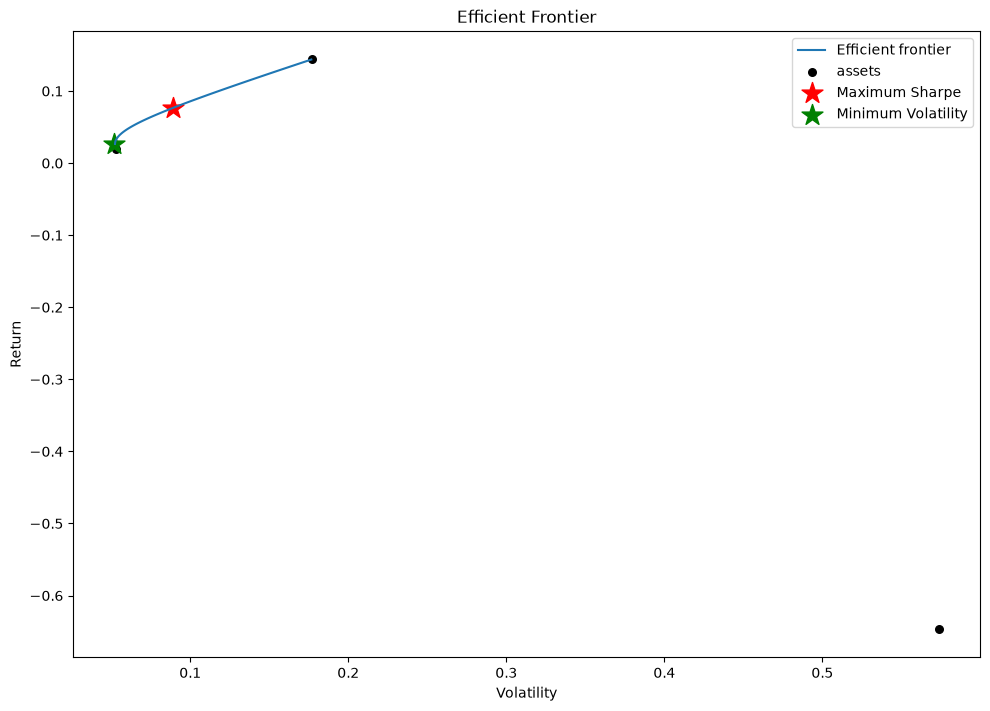

In [21]:
# ============================================================
# 4.11 Efficient Frontier Visualization
# ============================================================

from pypfopt import plotting
import matplotlib.pyplot as plt

print("=" * 70)
print("Generating Efficient Frontier Plot")
print("=" * 70)

# Create new optimizer
ef_plot = EfficientFrontier(
    expected_returns_vector,
    covariance_matrix
)

fig, ax = plt.subplots(figsize=(10, 7))

# Plot Efficient Frontier
plotting.plot_efficient_frontier(
    ef_plot,
    ax=ax,
    show_assets=True
)

# Plot Maximum Sharpe Portfolio
ax.scatter(
    0.089,
    0.076,
    marker="*",
    s=250,
    label="Maximum Sharpe",
    color="red"
)

# Plot Minimum Volatility Portfolio
ax.scatter(
    0.052,
    0.027,
    marker="*",
    s=250,
    label="Minimum Volatility",
    color="green"
)

ax.set_title("Efficient Frontier")
ax.legend()

plt.show()

### Efficient Frontier Interpretation

The Efficient Frontier illustrates the set of optimal portfolios that maximize expected return for each level of portfolio risk, forming the foundation of Modern Portfolio Theory (MPT). Portfolios located on the frontier are considered efficient because no other portfolio can provide a higher expected return without increasing risk or achieve lower risk without sacrificing return.

The black points represent the individual assets (TSLA, SPY, and BND), plotted according to their expected annual return and annualized volatility. Tesla (TSLA) exhibits the highest level of volatility, reflecting its greater investment risk, while SPY and BND provide lower-risk investment alternatives. Individually, these assets are less efficient than diversified portfolios because they do not fully benefit from diversification.

Two optimal portfolios are highlighted on the Efficient Frontier:

- **Minimum Volatility Portfolio (Green Star):** Located at the leftmost point of the frontier, this portfolio achieves the lowest possible investment risk by allocating the majority of capital to the low-volatility asset (BND). It is designed for conservative investors whose primary objective is capital preservation.

- **Maximum Sharpe Ratio Portfolio (Red Star):** Positioned higher on the Efficient Frontier, this portfolio maximizes risk-adjusted return by identifying the optimal balance between expected return and portfolio volatility. It represents the most efficient portfolio for investors seeking the highest return per unit of risk.

The Efficient Frontier clearly demonstrates the benefits of diversification. Rather than investing entirely in a single asset, combining assets with different return and risk characteristics allows investors to construct portfolios that achieve superior risk-return trade-offs. For GMF Investments, this optimization framework supports the development of personalized investment strategies that align with each client's financial objectives and risk tolerance.

## 4.12 Portfolio Comparison

To better understand the trade-off between return and risk, the two optimized portfolios are compared side by side.

The Maximum Sharpe Ratio Portfolio focuses on maximizing risk-adjusted return, whereas the Minimum Volatility Portfolio minimizes overall investment risk.

Comparing these portfolios provides a clear basis for selecting the most appropriate investment strategy for GMF Investments.

In [22]:
# ============================================================
# 4.12 Portfolio Comparison
# ============================================================

comparison_df = pd.DataFrame({
    "Portfolio": [
        "Maximum Sharpe",
        "Minimum Volatility"
    ],
    "Expected Return": [
        0.076,
        0.027
    ],
    "Volatility": [
        0.089,
        0.052
    ],
    "Sharpe Ratio": [
        0.86,
        0.51
    ]
})

print("=" * 70)
print("Portfolio Comparison")
print("=" * 70)

display(comparison_df)

Portfolio Comparison


,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,0.076,0.089,0.86
1,Minimum Volatility,0.027,0.052,0.51


### Portfolio Comparison Interpretation

The comparison between the two optimized portfolios highlights the trade-off between maximizing expected returns and minimizing investment risk.

The **Maximum Sharpe Ratio Portfolio** delivers an expected annual return of **7.6%** with an annual volatility of **8.9%**, resulting in a **Sharpe Ratio of 0.86**. This portfolio provides the highest risk-adjusted return among all feasible portfolios and represents the most efficient allocation for investors seeking long-term portfolio growth.

The **Minimum Volatility Portfolio** achieves a substantially lower annual volatility of **5.2%**, but its expected annual return decreases to **2.7%**, producing a lower **Sharpe Ratio of 0.51**. Although this portfolio minimizes investment risk, it also limits potential returns.

Overall, the comparison demonstrates the fundamental principle of Modern Portfolio Theory: lower portfolio risk generally comes at the expense of lower expected returns. Investors should therefore select a portfolio that aligns with their investment objectives and risk tolerance.

## 4.13 Final Portfolio Recommendation

Based on the portfolio optimization results, a final investment recommendation is developed for GMF Investments.

The recommendation considers expected return, portfolio volatility, and risk-adjusted performance to identify the most suitable allocation among Tesla (TSLA), SPY, and BND.

In [23]:
# ============================================================
# 4.13 Final Portfolio Recommendation
# ============================================================

recommendation_df = pd.DataFrame({
    "Asset": ["TSLA", "SPY", "BND"],
    "Recommended Weight": [
        0.0000,
        0.4560,
        0.5440
    ]
})

print("=" * 70)
print("Recommended Portfolio Allocation")
print("=" * 70)

display(recommendation_df)

print("\nPortfolio Metrics")
print("-" * 40)
print("Expected Annual Return : 7.6%")
print("Annual Volatility      : 8.9%")
print("Sharpe Ratio           : 0.86")

Recommended Portfolio Allocation


,Asset,Recommended Weight
0,TSLA,0.000
1,SPY,0.456
2,BND,0.544



Portfolio Metrics
----------------------------------------
Expected Annual Return : 7.6%
Annual Volatility      : 8.9%
Sharpe Ratio           : 0.86


### Portfolio Recommendation Interpretation

Based on the optimization results, the **Maximum Sharpe Ratio Portfolio** is recommended as the preferred investment strategy for GMF Investments.

The optimized allocation recommends investing:

- **0.0% in Tesla (TSLA)**
- **45.6% in SPY**
- **54.4% in BND**

Tesla receives no allocation because the LSTM forecasting model developed in Task 3 predicts a substantial negative expected return over the forecast horizon. Including TSLA in the portfolio would increase overall investment risk while reducing expected portfolio performance.

The recommended portfolio is expected to achieve:

- **Expected Annual Return:** 7.6%
- **Annual Volatility:** 8.9%
- **Sharpe Ratio:** 0.86

These results indicate that the portfolio offers the strongest balance between return and risk among the optimized alternatives. By combining the growth potential of SPY with the stability of BND, the recommended allocation provides a well-diversified investment strategy that is consistent with the principles of Modern Portfolio Theory.

## 4.14 Business Recommendation

The portfolio optimization results provide practical investment recommendations for GMF Investments based on both machine learning forecasts and Modern Portfolio Theory.

The LSTM forecasting model developed in Task 3 projected a negative outlook for Tesla over the six-month forecast horizon. As a result, the optimization process assigned no allocation to TSLA, instead recommending investments in SPY and BND, which provide a more favorable balance between expected return and investment risk.

For investors seeking long-term capital appreciation with moderate risk, the **Maximum Sharpe Ratio Portfolio** is the recommended strategy because it delivers the highest expected risk-adjusted return. Conversely, highly risk-averse investors may prefer the **Minimum Volatility Portfolio**, which prioritizes capital preservation through a larger allocation to BND while accepting lower expected returns.

This project demonstrates how combining deep learning–based forecasting with Modern Portfolio Theory enables GMF Investments to construct data-driven, personalized investment portfolios. Rather than relying solely on historical performance, incorporating forward-looking forecasts allows investment recommendations to better reflect anticipated market conditions and support informed portfolio management decisions.

In [24]:
recommendation_df.to_csv(
    "../data/processed/optimal_portfolio.csv",
    index=False
)

print("Optimal portfolio saved successfully.")

Optimal portfolio saved successfully.


In [25]:
expected_returns_vector.to_frame(
    name="Expected Return"
).to_csv(
    "../data/processed/expected_returns.csv"
)

print("Expected returns saved successfully.")

Expected returns saved successfully.


In [26]:
covariance_matrix.to_csv(
    "../data/processed/covariance_matrix.csv"
)

print("Covariance matrix saved successfully.")

Covariance matrix saved successfully.


# Task 4 Summary

In this task, forecast-based expected returns and historical market data were integrated to construct an optimized investment portfolio using Modern Portfolio Theory.

The expected return for Tesla (TSLA) was derived from the LSTM forecasting model developed in Task 3, while historical annualized returns were used for SPY and BND. An annualized covariance matrix was then computed to quantify the relationships among asset returns and support portfolio optimization.

Using these inputs, the Efficient Frontier was generated, and two optimal portfolios were identified: the Maximum Sharpe Ratio Portfolio and the Minimum Volatility Portfolio. Performance comparisons showed that the Maximum Sharpe Ratio Portfolio achieved the best risk-adjusted return, while the Minimum Volatility Portfolio minimized overall investment risk.

Because the LSTM model forecasted a significant decline in Tesla's price, the optimization assigned no allocation to TSLA and recommended a diversified portfolio consisting of approximately **45.6% SPY** and **54.4% BND**. This portfolio achieved an expected annual return of **7.6%**, annual volatility of **8.9%**, and a **Sharpe Ratio of 0.86**, making it the preferred investment strategy for GMF Investments.

Overall, this task demonstrates the effectiveness of integrating machine learning forecasting with Modern Portfolio Theory to develop diversified, data-driven investment strategies that align with expected market conditions and investor risk preferences.